# Stage 4 - Sleep Outcome Modeling Frame

This notebook audits the reusable Stage 4 `day D -> next sleep` modeling frame. It checks row eligibility, target availability, split assignment, missingness, feature-set sizes, and aggregate candidate review.

It does not fit models or make final performance claims.

## Setup

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/wearable-analytics-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def plot_local_component_trend(
    ax,
    data: pd.DataFrame,
    *,
    x_col: str,
    y_col: str,
    color: str = "#222222",
    window_days: int = 75,
) -> None:
    trend = data[[x_col, y_col]].dropna().copy()
    if len(trend) < 10:
        return
    trend[x_col] = pd.to_datetime(trend[x_col])
    trend = trend.groupby(x_col, as_index=False)[y_col].mean().sort_values(x_col)
    min_periods = max(6, min(18, len(trend) // 10))
    smoothed = (
        trend.set_index(x_col)[y_col]
        .rolling(f"{window_days}D", center=True, min_periods=min_periods)
        .median()
        .dropna()
    )
    if len(smoothed) >= 2:
        ax.plot(
            smoothed.index,
            smoothed.to_numpy(),
            color=color,
            linewidth=2.3,
            alpha=0.92,
            label=f"{window_days}-day local median trend",
        )

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from garmin_analytics.modeling.stage4 import (
    STAGE4_NON_MODELING_LABEL,
    STAGE4_PRIMARY_TARGET,
    STAGE4_SPLIT_COLUMN,
    STAGE4_TARGET_COLUMNS,
    split_summary,
)

frame_path = repo_root / "data" / "processed" / "stage4_sleep_modeling_frame.parquet"
feature_catalog_path = repo_root / "reports" / "stage4_sleep_modeling_feature_sets.csv"
summary_path = repo_root / "reports" / "stage4_sleep_modeling_frame_summary.md"

for path in [frame_path, feature_catalog_path, summary_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing expected Stage 4 modeling artifact: {path}")

frame = pd.read_parquet(frame_path)
feature_catalog = pd.read_csv(feature_catalog_path)

print("repo_root:", repo_root)
print("frame shape:", frame.shape)
print("feature catalog rows:", len(feature_catalog))

repo_root: /Users/abatrakov/Documents/FUN/wearable-analytics
frame shape: (589, 295)
feature catalog rows: 350


## Frame Shape And Date Span

In [2]:
date_span = pd.DataFrame(
    [
        {
            "rows": len(frame),
            "columns": frame.shape[1],
            "start_date": pd.to_datetime(frame["calendarDate"]).min().date(),
            "end_date": pd.to_datetime(frame["calendarDate"]).max().date(),
            "analysis_windows": frame["analysis_window_id"].nunique(),
        }
    ]
)
display(date_span)

,rows,columns,start_date,end_date,analysis_windows
0,589,295,2023-05-27,2026-05-18,589


## Eligibility And Target Availability

In [3]:
eligible = pd.to_numeric(frame["modeling_recovery_v0_eligible"], errors="coerce").fillna(0).astype(int).eq(1)
primary_target_available = pd.to_numeric(frame[STAGE4_PRIMARY_TARGET], errors="coerce").notna()
modeling_rows = frame[STAGE4_SPLIT_COLUMN].isin(["train", "valid", "test"])

availability = pd.DataFrame(
    [
        {"metric": "analysis_rows", "rows": len(frame)},
        {"metric": "eligible_rows", "rows": int(eligible.sum())},
        {"metric": "primary_target_available", "rows": int(primary_target_available.sum())},
        {"metric": "eligible_with_primary_target", "rows": int((eligible & primary_target_available).sum())},
        {"metric": "split_assigned_modeling_rows", "rows": int(modeling_rows.sum())},
    ]
)
display(availability)

target_availability = pd.DataFrame(
    [
        {
            "target": target,
            "available_rows": int(pd.to_numeric(frame[target], errors="coerce").notna().sum()),
        }
        for target in STAGE4_TARGET_COLUMNS
        if target in frame.columns
    ]
)
display(target_availability)

,metric,rows
0,analysis_rows,589
1,eligible_rows,472
2,primary_target_available,524
3,eligible_with_primary_target,472
4,split_assigned_modeling_rows,472


,target,available_rows
0,target_avgSleepStress_next_sleep,524
1,target_sleepRecoveryScore_next_sleep,523
2,target_sleepOverallScore_next_sleep,523
3,target_sleepQualityScore_next_sleep,523
4,target_sleep_opportunity_hours_next_sleep,524
5,target_sleep_start_hour_local_wrapped_next_sleep,524


## Eligibility Funnel Plot

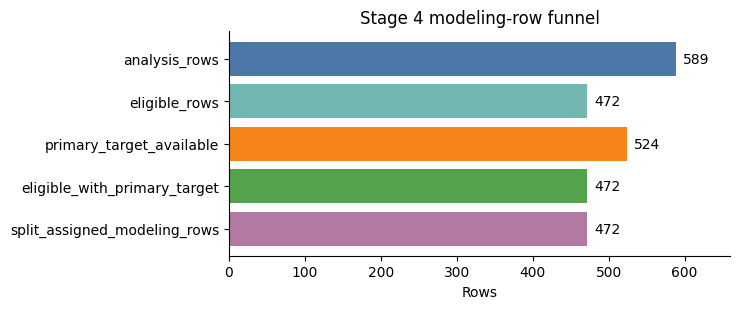

In [4]:
funnel = availability.copy()
fig, ax = plt.subplots(figsize=(7.5, 3.2))
colors = ["#4c78a8", "#72b7b2", "#f58518", "#54a24b", "#b279a2"]
ax.barh(funnel["metric"], funnel["rows"], color=colors[: len(funnel)])
ax.invert_yaxis()
ax.set_xlabel("Rows")
ax.set_title("Stage 4 modeling-row funnel")
x_padding = max(funnel["rows"].max() * 0.015, 3)
for idx, row in funnel.iterrows():
    ax.text(row["rows"] + x_padding, idx, f"{row['rows']:,}", va="center")
ax.set_xlim(0, funnel["rows"].max() * 1.12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Sleep Stress Source Consistency

,paired_rows,pearson,spearman,mean_delta_aggregate_minus_minute,median_abs_delta
0,555,0.890552,0.851553,1.50724,1.499629


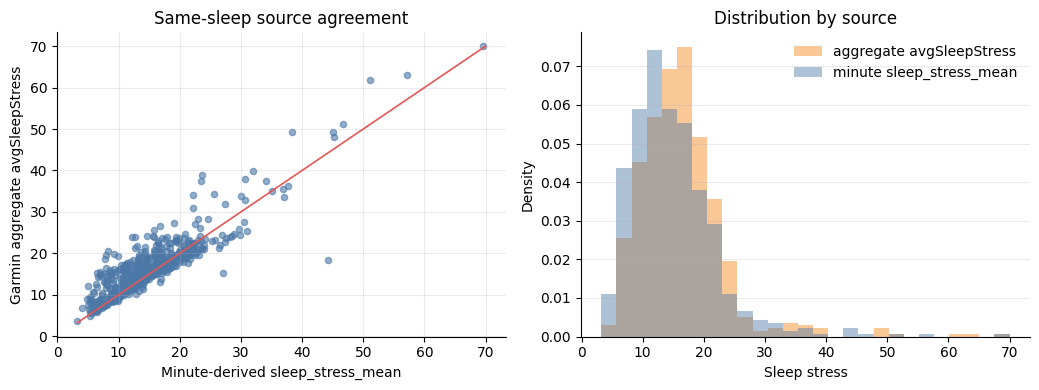

In [5]:
minute_sleep_stress_column = "sleep_stress_mean"
garmin_sleep_stress_column = "garmin_avgSleepStress_same_sleep"
quality_index_path = repo_root / "data" / "processed" / "monitoring_quality_index.parquet"
sleep_source_path = repo_root / "data" / "processed" / "sleep_sanitized.parquet"
if not sleep_source_path.exists():
    sleep_source_path = repo_root / "data" / "processed" / "sleep.parquet"

if not quality_index_path.exists() or not sleep_source_path.exists():
    raise FileNotFoundError("Sleep stress source audit needs monitoring_quality_index.parquet and a sleep parquet source.")

quality_index = pd.read_parquet(quality_index_path)
sleep_source = pd.read_parquet(sleep_source_path)

quality_sleep_keys = quality_index[["analysis_window_id", "sleep_start_utc"]].copy()
quality_sleep_keys["sleep_start_utc"] = pd.to_datetime(
    quality_sleep_keys["sleep_start_utc"], errors="coerce", utc=True
)

sleep_source = sleep_source.copy()
sleep_start_numeric = pd.to_numeric(sleep_source["sleepStartTimestampGMT"], errors="coerce")
if sleep_start_numeric.notna().sum() > 0:
    sleep_source["sleep_start_utc"] = pd.to_datetime(sleep_start_numeric, unit="s", errors="coerce", utc=True)
else:
    sleep_source["sleep_start_utc"] = pd.to_datetime(sleep_source["sleepStartTimestampGMT"], errors="coerce", utc=True)
sleep_source[garmin_sleep_stress_column] = pd.to_numeric(sleep_source["avgSleepStress"], errors="coerce")

sleep_stress_compare = (
    frame[["analysis_window_id", minute_sleep_stress_column]]
    .merge(quality_sleep_keys, on="analysis_window_id", how="left")
    .merge(
        sleep_source[["sleep_start_utc", garmin_sleep_stress_column]],
        on="sleep_start_utc",
        how="left",
    )
)
sleep_stress_compare[minute_sleep_stress_column] = pd.to_numeric(
    sleep_stress_compare[minute_sleep_stress_column], errors="coerce"
)
sleep_stress_compare = sleep_stress_compare.dropna(subset=[garmin_sleep_stress_column, minute_sleep_stress_column])
sleep_stress_compare["aggregate_minus_minute_mean"] = (
    sleep_stress_compare[garmin_sleep_stress_column] - sleep_stress_compare[minute_sleep_stress_column]
)

source_consistency = pd.DataFrame(
    [
        {
            "paired_rows": len(sleep_stress_compare),
            "pearson": sleep_stress_compare[garmin_sleep_stress_column].corr(
                sleep_stress_compare[minute_sleep_stress_column], method="pearson"
            ),
            "spearman": sleep_stress_compare[garmin_sleep_stress_column].corr(
                sleep_stress_compare[minute_sleep_stress_column], method="spearman"
            ),
            "mean_delta_aggregate_minus_minute": sleep_stress_compare["aggregate_minus_minute_mean"].mean(),
            "median_abs_delta": sleep_stress_compare["aggregate_minus_minute_mean"].abs().median(),
        }
    ]
)
display(source_consistency)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].scatter(
    sleep_stress_compare[minute_sleep_stress_column],
    sleep_stress_compare[garmin_sleep_stress_column],
    s=20,
    alpha=0.6,
    color="#4c78a8",
)
stress_min = float(sleep_stress_compare[[garmin_sleep_stress_column, minute_sleep_stress_column]].min().min())
stress_max = float(sleep_stress_compare[[garmin_sleep_stress_column, minute_sleep_stress_column]].max().max())
axes[0].plot([stress_min, stress_max], [stress_min, stress_max], color="#e45756", linewidth=1.2)
axes[0].set_xlabel("Minute-derived sleep_stress_mean")
axes[0].set_ylabel("Garmin aggregate avgSleepStress")
axes[0].set_title("Same-sleep source agreement")
axes[0].grid(alpha=0.25)

bins = np.linspace(stress_min, stress_max, 28)
axes[1].hist(
    sleep_stress_compare[garmin_sleep_stress_column],
    bins=bins,
    density=True,
    alpha=0.45,
    label="aggregate avgSleepStress",
    color="#f58518",
)
axes[1].hist(
    sleep_stress_compare[minute_sleep_stress_column],
    bins=bins,
    density=True,
    alpha=0.45,
    label="minute sleep_stress_mean",
    color="#4c78a8",
)
axes[1].set_xlabel("Sleep stress")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution by source")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.25)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Boundary And Split Audit

In [6]:
boundary_summary = (
    frame.assign(
        eligible=eligible,
        primary_target_available=primary_target_available,
        modeling_row=modeling_rows,
    )
    .groupby("boundary_confidence", dropna=False)
    .agg(
        rows=("analysis_window_id", "count"),
        eligible_rows=("eligible", "sum"),
        primary_target_rows=("primary_target_available", "sum"),
        modeling_rows=("modeling_row", "sum"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)
display(boundary_summary)

splits = split_summary(frame)
display(splits)

test_start = pd.to_datetime(frame.loc[frame[STAGE4_SPLIT_COLUMN] == "test", "calendarDate"]).min()
past_max = pd.to_datetime(frame.loc[frame[STAGE4_SPLIT_COLUMN].isin(["train", "valid"]), "calendarDate"]).max()
assert past_max < test_start, "Future test block should start after all train/validation modeling rows."

,boundary_confidence,rows,eligible_rows,primary_target_rows,modeling_rows
1,observed,490,471,490,471
3,synthetic_split,66,0,33,0
4,unsupported_multi_day_gap,31,0,0,0
0,missing_next_sleep,1,0,0,0
2,observed_late_within_duration,1,1,1,1


,split,rows,eligible_rows,primary_target_rows,start_date,end_date
0,train,330,330,330,2023-05-27,2026-01-28
1,valid,71,71,71,2023-06-12,2026-01-20
2,test,71,71,71,2026-01-29,2026-05-13
3,not_eligible_or_missing_target,117,0,52,2023-07-10,2026-05-18


## Split Timeline And Target Shape

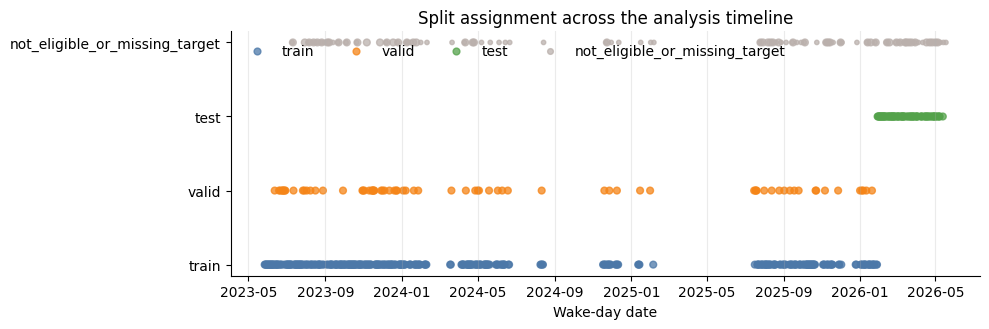

In [7]:
split_plot_order = ["train", "valid", "test", STAGE4_NON_MODELING_LABEL]
split_y = {label: idx for idx, label in enumerate(split_plot_order)}
split_colors = {
    "train": "#4c78a8",
    "valid": "#f58518",
    "test": "#54a24b",
    STAGE4_NON_MODELING_LABEL: "#bab0ac",
}

timeline = frame[["calendarDate", STAGE4_SPLIT_COLUMN, STAGE4_PRIMARY_TARGET]].copy()
timeline["calendarDate"] = pd.to_datetime(timeline["calendarDate"])
timeline["split_y"] = timeline[STAGE4_SPLIT_COLUMN].map(split_y)
timeline["target_available"] = pd.to_numeric(timeline[STAGE4_PRIMARY_TARGET], errors="coerce").notna()

fig, ax = plt.subplots(figsize=(10, 3.4))
for split_label in split_plot_order:
    subset = timeline.loc[timeline[STAGE4_SPLIT_COLUMN] == split_label]
    if subset.empty:
        continue
    point_sizes = subset["target_available"].map({True: 24, False: 10})
    ax.scatter(
        subset["calendarDate"],
        subset["split_y"],
        s=point_sizes,
        alpha=0.75,
        color=split_colors[split_label],
        label=split_label,
    )
ax.set_yticks(range(len(split_plot_order)), split_plot_order)
ax.set_xlabel("Wake-day date")
ax.set_title("Split assignment across the analysis timeline")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", ncols=4, frameon=False)
plt.tight_layout()
plt.show()

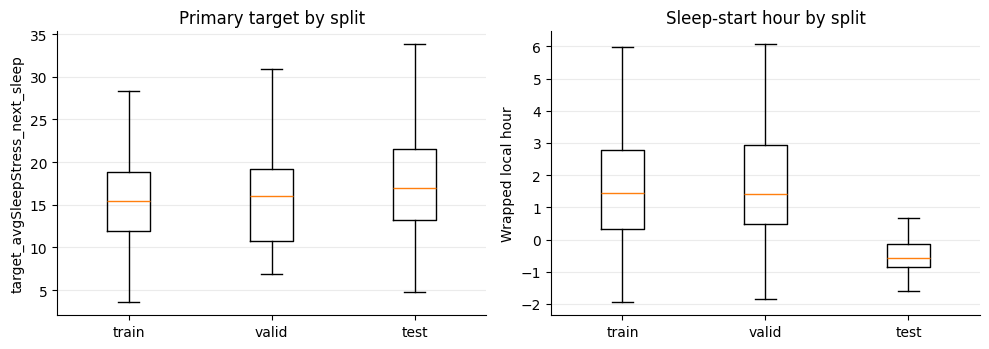

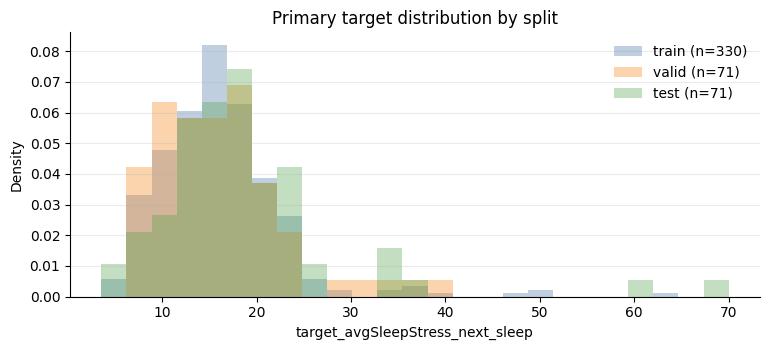

In [8]:
modeling_plot = frame.loc[frame[STAGE4_SPLIT_COLUMN].isin(["train", "valid", "test"])].copy()
modeling_plot[STAGE4_PRIMARY_TARGET] = pd.to_numeric(modeling_plot[STAGE4_PRIMARY_TARGET], errors="coerce")
modeling_plot["next_sleep_start_hour_local_wrapped"] = pd.to_numeric(
    modeling_plot["next_sleep_start_hour_local_wrapped"], errors="coerce"
)

target_by_split = [
    modeling_plot.loc[modeling_plot[STAGE4_SPLIT_COLUMN] == split_label, STAGE4_PRIMARY_TARGET].dropna()
    for split_label in ["train", "valid", "test"]
]
sleep_start_by_split = [
    modeling_plot.loc[
        modeling_plot[STAGE4_SPLIT_COLUMN] == split_label,
        "next_sleep_start_hour_local_wrapped",
    ].dropna()
    for split_label in ["train", "valid", "test"]
]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].boxplot(target_by_split, showfliers=False)
axes[0].set_xticks([1, 2, 3], ["train", "valid", "test"])
axes[0].set_title("Primary target by split")
axes[0].set_ylabel(STAGE4_PRIMARY_TARGET)
axes[0].grid(axis="y", alpha=0.25)

axes[1].boxplot(sleep_start_by_split, showfliers=False)
axes[1].set_xticks([1, 2, 3], ["train", "valid", "test"])
axes[1].set_title("Sleep-start hour by split")
axes[1].set_ylabel("Wrapped local hour")
axes[1].grid(axis="y", alpha=0.25)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

target_values = modeling_plot[STAGE4_PRIMARY_TARGET].dropna()
target_bins = np.linspace(float(target_values.min()), float(target_values.max()), 26)
fig, ax = plt.subplots(figsize=(7.8, 3.6))
for split_label in ["train", "valid", "test"]:
    subset = modeling_plot.loc[modeling_plot[STAGE4_SPLIT_COLUMN] == split_label, STAGE4_PRIMARY_TARGET].dropna()
    ax.hist(
        subset,
        bins=target_bins,
        density=True,
        alpha=0.35,
        label=f"{split_label} (n={len(subset)})",
        color=split_colors[split_label],
    )
ax.set_xlabel(STAGE4_PRIMARY_TARGET)
ax.set_ylabel("Density")
ax.set_title("Primary target distribution by split")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Contiguous Split Sensitivity Audit

,rows,start_date,end_date,primary_target_mean,primary_target_median
split_contiguous_time_audit,,,,,
train,330,2023-05-27,2025-09-12,16.417061,15.755000
valid,71,2025-09-13,2026-01-28,14.972535,14.560000
test,71,2026-01-29,2026-05-13,18.767465,16.959999


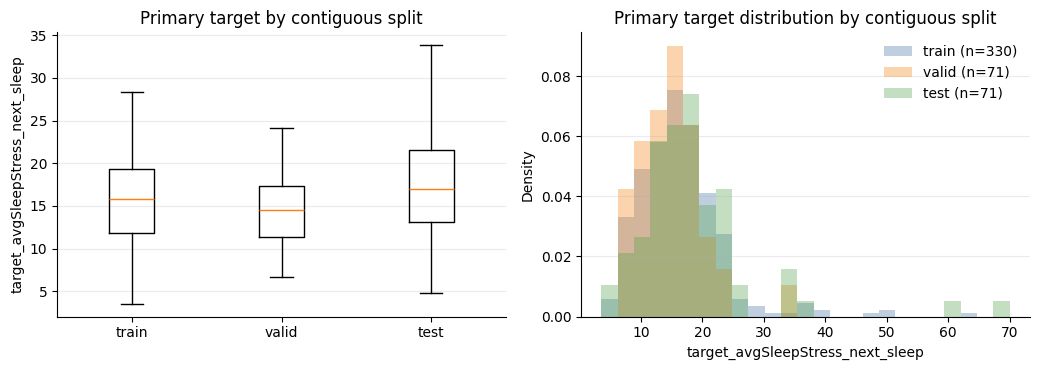

,feature_set,rows_projected,train_rows_fit,numeric_features_used,non_numeric_sparse_or_constant_skipped
0,aggregate_plus_monitoring_full,472,330,136,2


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.284722,0.284722
1,PC2,0.111254,0.395976
2,PC3,0.087616,0.483591
3,PC4,0.052357,0.535948
4,PC5,0.047538,0.583486


,rows,PC1_mean,PC1_std,PC2_mean,PC2_std
split_contiguous_time_audit,,,,,
train,330,-1.372639e-16,6.232164,4.575465e-17,3.895704
valid,71,3.173510e+00,6.182722,-2.901875e+00,3.565358
test,71,5.009730e+00,5.696357,-2.985085e+00,3.881827


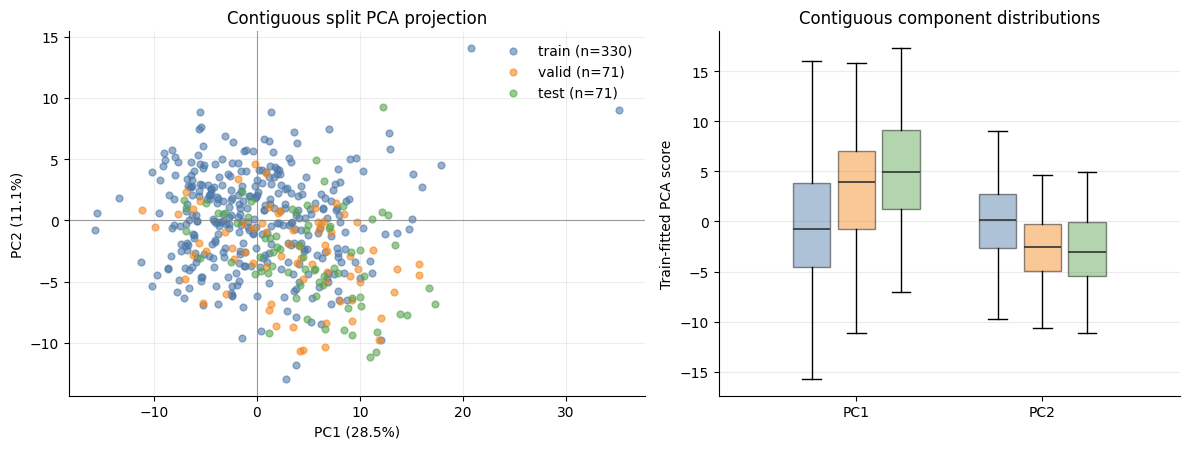

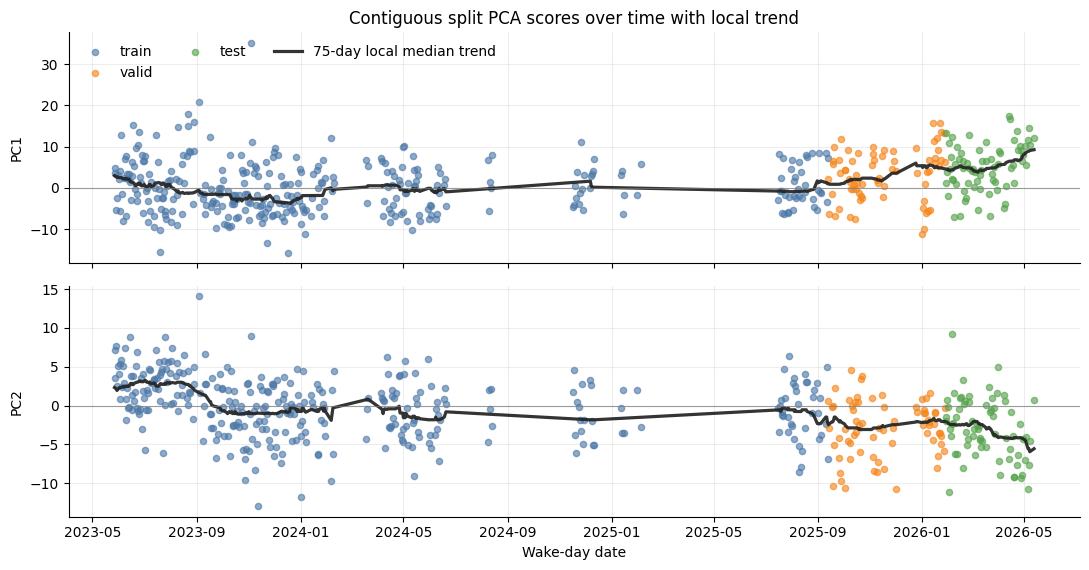

In [9]:
from sklearn.decomposition import PCA as AuditPCA
from sklearn.impute import SimpleImputer as AuditSimpleImputer
from sklearn.preprocessing import StandardScaler as AuditStandardScaler

contiguous_split_column = "split_contiguous_time_audit"
contiguous_split_order = ["train", "valid", "test"]
contiguous_split_colors = {"train": "#4c78a8", "valid": "#f58518", "test": "#54a24b"}

contiguous_labels = pd.Series(STAGE4_NON_MODELING_LABEL, index=frame.index, dtype="object")
ordered_modeling_index = (
    frame.loc[modeling_rows]
    .assign(calendarDate=pd.to_datetime(frame.loc[modeling_rows, "calendarDate"]))
    .sort_values(["calendarDate", "analysis_window_id"])
    .index
)
current_modeling_counts = frame.loc[modeling_rows, STAGE4_SPLIT_COLUMN].value_counts()
contiguous_train_n = int(current_modeling_counts.get("train", 0))
contiguous_valid_n = int(current_modeling_counts.get("valid", 0))
contiguous_test_n = int(current_modeling_counts.get("test", 0))

contiguous_labels.loc[ordered_modeling_index[:contiguous_train_n]] = "train"
contiguous_labels.loc[
    ordered_modeling_index[contiguous_train_n : contiguous_train_n + contiguous_valid_n]
] = "valid"
contiguous_labels.loc[
    ordered_modeling_index[contiguous_train_n + contiguous_valid_n : contiguous_train_n + contiguous_valid_n + contiguous_test_n]
] = "test"

contiguous_split_summary = (
    frame.assign(**{contiguous_split_column: contiguous_labels})
    .loc[lambda df: df[contiguous_split_column].isin(contiguous_split_order)]
    .assign(calendarDate=lambda df: pd.to_datetime(df["calendarDate"]))
    .groupby(contiguous_split_column)
    .agg(
        rows=("analysis_window_id", "count"),
        start_date=("calendarDate", lambda values: values.min().date()),
        end_date=("calendarDate", lambda values: values.max().date()),
        primary_target_mean=(STAGE4_PRIMARY_TARGET, "mean"),
        primary_target_median=(STAGE4_PRIMARY_TARGET, "median"),
    )
    .reindex(contiguous_split_order)
)
display(contiguous_split_summary)

contiguous_plot = frame.loc[contiguous_labels.isin(contiguous_split_order), [STAGE4_PRIMARY_TARGET]].copy()
contiguous_plot[contiguous_split_column] = contiguous_labels.loc[contiguous_plot.index].to_numpy()
contiguous_plot[STAGE4_PRIMARY_TARGET] = pd.to_numeric(contiguous_plot[STAGE4_PRIMARY_TARGET], errors="coerce")

contiguous_target_by_split = [
    contiguous_plot.loc[contiguous_plot[contiguous_split_column] == split_label, STAGE4_PRIMARY_TARGET].dropna()
    for split_label in contiguous_split_order
]
contiguous_target_values = contiguous_plot[STAGE4_PRIMARY_TARGET].dropna()
contiguous_target_bins = np.linspace(float(contiguous_target_values.min()), float(contiguous_target_values.max()), 26)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].boxplot(contiguous_target_by_split, showfliers=False)
axes[0].set_xticks([1, 2, 3], contiguous_split_order)
axes[0].set_title("Primary target by contiguous split")
axes[0].set_ylabel(STAGE4_PRIMARY_TARGET)
axes[0].grid(axis="y", alpha=0.25)

for split_label in contiguous_split_order:
    subset = contiguous_plot.loc[contiguous_plot[contiguous_split_column] == split_label, STAGE4_PRIMARY_TARGET].dropna()
    axes[1].hist(
        subset,
        bins=contiguous_target_bins,
        density=True,
        alpha=0.35,
        label=f"{split_label} (n={len(subset)})",
        color=contiguous_split_colors[split_label],
    )
axes[1].set_xlabel(STAGE4_PRIMARY_TARGET)
axes[1].set_ylabel("Density")
axes[1].set_title("Primary target distribution by contiguous split")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=False)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

contiguous_pca_feature_set = "aggregate_plus_monitoring_full"
contiguous_pca_features = (
    feature_catalog.loc[feature_catalog["feature_set"] == contiguous_pca_feature_set, "feature"]
    .drop_duplicates()
    .tolist()
)
contiguous_pca_features = [feature for feature in contiguous_pca_features if feature in frame.columns]
contiguous_pca_rows = frame.loc[
    contiguous_labels.isin(contiguous_split_order),
    contiguous_pca_features,
].copy()
contiguous_pca_rows[contiguous_split_column] = contiguous_labels.loc[contiguous_pca_rows.index].to_numpy()
contiguous_pca_train_mask = contiguous_pca_rows[contiguous_split_column].eq("train")

contiguous_pca_numeric = {}
for feature in contiguous_pca_features:
    values = pd.to_numeric(contiguous_pca_rows[feature], errors="coerce").replace([np.inf, -np.inf], np.nan)
    train_values = values.loc[contiguous_pca_train_mask]
    if train_values.notna().sum() >= 50 and train_values.nunique(dropna=True) > 1:
        contiguous_pca_numeric[feature] = values

contiguous_pca_x = pd.DataFrame(contiguous_pca_numeric, index=contiguous_pca_rows.index)
contiguous_pca_imputer = AuditSimpleImputer(strategy="median")
contiguous_pca_scaler = AuditStandardScaler()
contiguous_pca_train_scaled = contiguous_pca_scaler.fit_transform(
    contiguous_pca_imputer.fit_transform(contiguous_pca_x.loc[contiguous_pca_train_mask])
)
contiguous_pca_component_count = min(5, contiguous_pca_train_scaled.shape[0], contiguous_pca_train_scaled.shape[1])
contiguous_pca_model = AuditPCA(n_components=contiguous_pca_component_count, random_state=42)
contiguous_pca_model.fit(contiguous_pca_train_scaled)
contiguous_pca_all_scaled = contiguous_pca_scaler.transform(contiguous_pca_imputer.transform(contiguous_pca_x))
contiguous_pca_scores = pd.DataFrame(
    contiguous_pca_model.transform(contiguous_pca_all_scaled),
    columns=[f"PC{i + 1}" for i in range(contiguous_pca_component_count)],
    index=contiguous_pca_x.index,
)
contiguous_pca_scores[contiguous_split_column] = contiguous_pca_rows[contiguous_split_column].to_numpy()
contiguous_pca_scores["calendarDate"] = pd.to_datetime(frame.loc[contiguous_pca_scores.index, "calendarDate"]).to_numpy()

contiguous_pca_summary = pd.DataFrame(
    [
        {
            "feature_set": contiguous_pca_feature_set,
            "rows_projected": len(contiguous_pca_scores),
            "train_rows_fit": int(contiguous_pca_train_mask.sum()),
            "numeric_features_used": len(contiguous_pca_numeric),
            "non_numeric_sparse_or_constant_skipped": len(contiguous_pca_features) - len(contiguous_pca_numeric),
        }
    ]
)
display(contiguous_pca_summary)

display(
    pd.DataFrame(
        {
            "component": [f"PC{i + 1}" for i in range(contiguous_pca_component_count)],
            "explained_variance_ratio": contiguous_pca_model.explained_variance_ratio_,
            "cumulative_explained_variance": contiguous_pca_model.explained_variance_ratio_.cumsum(),
        }
    )
)

display(
    contiguous_pca_scores.groupby(contiguous_split_column)
    .agg(
        rows=("PC1", "size"),
        PC1_mean=("PC1", "mean"),
        PC1_std=("PC1", "std"),
        PC2_mean=("PC2", "mean"),
        PC2_std=("PC2", "std"),
    )
    .reindex(contiguous_split_order)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
for split_label in contiguous_split_order:
    subset = contiguous_pca_scores.loc[contiguous_pca_scores[contiguous_split_column] == split_label]
    axes[0].scatter(
        subset["PC1"],
        subset["PC2"],
        s=24,
        alpha=0.58,
        label=f"{split_label} (n={len(subset)})",
        color=contiguous_split_colors[split_label],
    )
axes[0].axhline(0, color="#777777", linewidth=0.8, alpha=0.7)
axes[0].axvline(0, color="#777777", linewidth=0.8, alpha=0.7)
axes[0].set_xlabel(f"PC1 ({contiguous_pca_model.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({contiguous_pca_model.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("Contiguous split PCA projection")
axes[0].grid(alpha=0.22)
axes[0].legend(frameon=False)
axes[0].spines[["top", "right"]].set_visible(False)

contiguous_pc_box_components = [component for component in ["PC1", "PC2"] if component in contiguous_pca_scores.columns]
box_data = []
box_positions = []
box_colors = []
split_offsets = {"train": -0.24, "valid": 0.0, "test": 0.24}
for component_index, component in enumerate(contiguous_pc_box_components, start=1):
    for split_label in contiguous_split_order:
        box_data.append(
            contiguous_pca_scores.loc[contiguous_pca_scores[contiguous_split_column] == split_label, component].dropna()
        )
        box_positions.append(component_index + split_offsets[split_label])
        box_colors.append(contiguous_split_colors[split_label])
boxplot = axes[1].boxplot(box_data, positions=box_positions, widths=0.20, patch_artist=True, showfliers=False)
for patch, color in zip(boxplot["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
for median in boxplot["medians"]:
    median.set_color("#333333")
    median.set_linewidth(1.2)
axes[1].set_xticks(range(1, len(contiguous_pc_box_components) + 1), contiguous_pc_box_components)
axes[1].set_title("Contiguous component distributions")
axes[1].set_ylabel("Train-fitted PCA score")
axes[1].grid(axis="y", alpha=0.25)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True)
for axis, component in zip(axes, ["PC1", "PC2"]):
    for split_label in contiguous_split_order:
        subset = contiguous_pca_scores.loc[contiguous_pca_scores[contiguous_split_column] == split_label]
        axis.scatter(
            subset["calendarDate"],
            subset[component],
            s=20,
            alpha=0.62,
            label=split_label,
            color=contiguous_split_colors[split_label],
        )
    plot_local_component_trend(axis, contiguous_pca_scores, x_col="calendarDate", y_col=component)
    axis.axhline(0, color="#777777", linewidth=0.8, alpha=0.7)
    axis.set_ylabel(component)
    axis.grid(alpha=0.22)
    axis.spines[["top", "right"]].set_visible(False)
axes[0].set_title("Contiguous split PCA scores over time with local trend")
axes[0].legend(frameon=False, ncols=3, loc="upper left")
axes[1].set_xlabel("Wake-day date")
plt.tight_layout()
plt.show()

## Feature Set Sizes

In [10]:
feature_set_sizes = (
    feature_catalog.groupby("feature_set", as_index=False)
    .agg(
        features=("feature", "nunique"),
        numeric_features=("dtype", lambda values: int(values.astype(str).str.lower().str.contains("int|float|bool").sum())),
        median_missing_pct=("modeling_missing_pct", "median"),
        max_missing_pct=("modeling_missing_pct", "max"),
    )
    .sort_values("feature_set")
)
display(feature_set_sizes)

,feature_set,features,numeric_features,median_missing_pct,max_missing_pct
0,aggregate_plus_monitoring_full,138,137,0.0,15.254237
1,aggregate_stage3_baseline,33,32,0.0,0.635593
2,monitoring_core_wake_pre_sleep,56,56,0.0,1.271186
3,monitoring_full_wake_pre_sleep,123,123,0.0,15.254237


## Feature Set Composition Plot

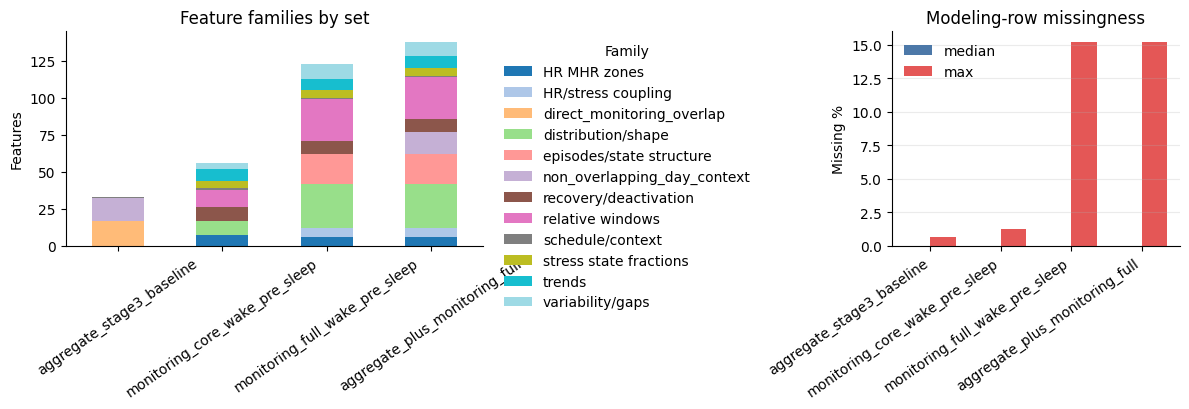

In [11]:
feature_set_order = [
    "aggregate_stage3_baseline",
    "monitoring_core_wake_pre_sleep",
    "monitoring_full_wake_pre_sleep",
    "aggregate_plus_monitoring_full",
]
family_pivot = (
    feature_catalog.groupby(["feature_set", "family"])
    .size()
    .unstack(fill_value=0)
    .reindex(feature_set_order)
    .fillna(0)
)
size_plot = feature_set_sizes.set_index("feature_set").reindex(feature_set_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.45, 1]})
family_pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20")
axes[0].set_title("Feature families by set")
axes[0].set_xlabel("")
axes[0].set_ylabel("Features")
axes[0].tick_params(axis="x", rotation=35)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(title="Family", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

x_positions = range(len(size_plot))
axes[1].bar(
    [x - 0.18 for x in x_positions],
    size_plot["median_missing_pct"],
    width=0.36,
    label="median",
    color="#4c78a8",
)
axes[1].bar(
    [x + 0.18 for x in x_positions],
    size_plot["max_missing_pct"],
    width=0.36,
    label="max",
    color="#e45756",
)
axes[1].set_xticks(list(x_positions), feature_set_order, rotation=35, ha="right")
axes[1].set_title("Modeling-row missingness")
axes[1].set_ylabel("Missing %")
axes[1].grid(axis="y", alpha=0.25)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## Train-Fit PCA Split Projection Audit

,feature_set,rows_projected,train_rows_fit,numeric_features_used,non_numeric_sparse_or_constant_skipped
0,aggregate_plus_monitoring_full,472,330,136,2


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.289299,0.289299
1,PC2,0.116714,0.406013
2,PC3,0.076298,0.482312
3,PC4,0.052175,0.534487
4,PC5,0.048453,0.582940


,rows,PC1_mean,PC1_std,PC2_mean,PC2_std
split_past_random_valid_future_test,,,,,
train,330,-2.422305e-16,6.282060,2.116152e-16,3.990161
valid,71,-9.559948e-02,5.804839,5.629735e-01,3.477013
test,71,4.420279e+00,5.650756,-2.197649e+00,3.874762


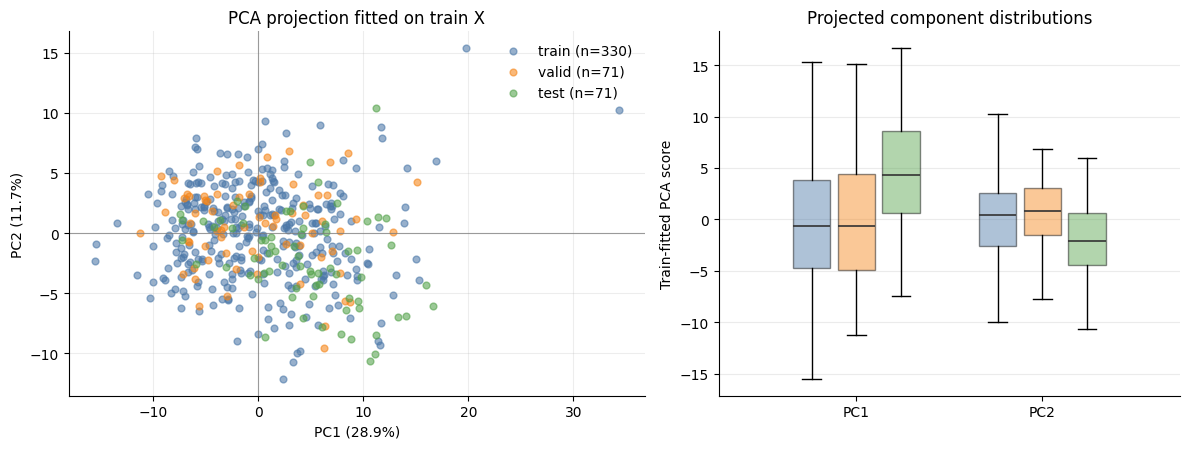

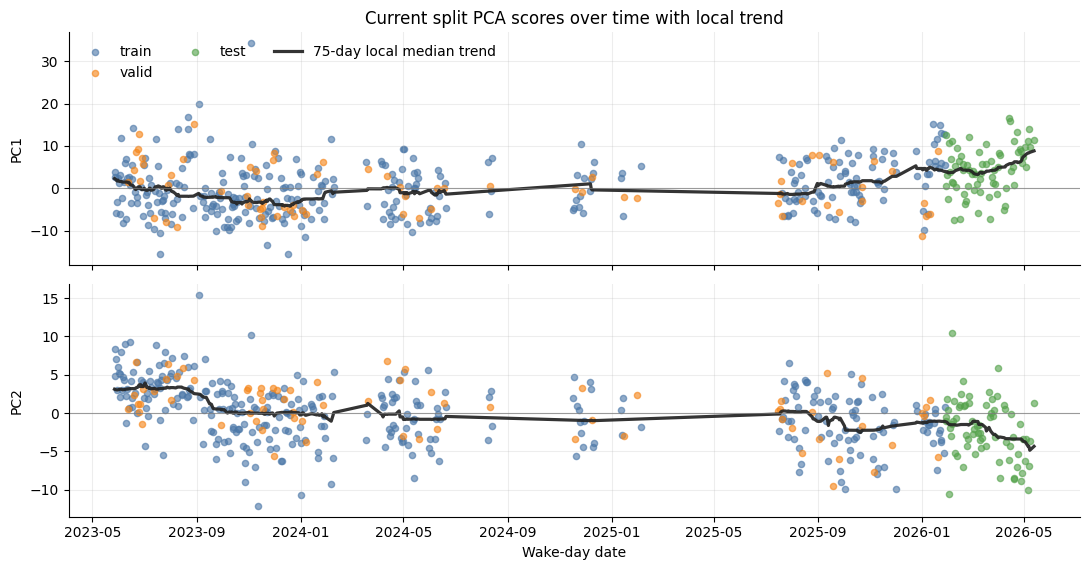

In [12]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pca_feature_set = "aggregate_plus_monitoring_full"
pca_split_order = ["train", "valid", "test"]
pca_split_colors = {"train": "#4c78a8", "valid": "#f58518", "test": "#54a24b"}

pca_candidate_features = (
    feature_catalog.loc[feature_catalog["feature_set"] == pca_feature_set, "feature"]
    .drop_duplicates()
    .tolist()
)
pca_candidate_features = [feature for feature in pca_candidate_features if feature in frame.columns]

pca_rows = frame.loc[
    frame[STAGE4_SPLIT_COLUMN].isin(pca_split_order),
    [STAGE4_SPLIT_COLUMN, *pca_candidate_features],
].copy()
pca_train_mask = pca_rows[STAGE4_SPLIT_COLUMN].eq("train")

pca_numeric_columns = {}
for feature in pca_candidate_features:
    values = pd.to_numeric(pca_rows[feature], errors="coerce").replace([np.inf, -np.inf], np.nan)
    train_values = values.loc[pca_train_mask]
    if train_values.notna().sum() >= 50 and train_values.nunique(dropna=True) > 1:
        pca_numeric_columns[feature] = values

pca_x = pd.DataFrame(pca_numeric_columns, index=pca_rows.index)
pca_train_x = pca_x.loc[pca_train_mask]

pca_imputer = SimpleImputer(strategy="median")
pca_scaler = StandardScaler()
pca_train_imputed = pca_imputer.fit_transform(pca_train_x)
pca_train_scaled = pca_scaler.fit_transform(pca_train_imputed)

pca_component_count = min(5, pca_train_scaled.shape[0], pca_train_scaled.shape[1])
pca_model = PCA(n_components=pca_component_count, random_state=42)
pca_model.fit(pca_train_scaled)

pca_all_scaled = pca_scaler.transform(pca_imputer.transform(pca_x))
pca_scores = pd.DataFrame(
    pca_model.transform(pca_all_scaled),
    columns=[f"PC{i + 1}" for i in range(pca_component_count)],
    index=pca_x.index,
)
pca_scores[STAGE4_SPLIT_COLUMN] = pca_rows[STAGE4_SPLIT_COLUMN].to_numpy()
pca_scores["calendarDate"] = pd.to_datetime(frame.loc[pca_scores.index, "calendarDate"]).to_numpy()

pca_summary = pd.DataFrame(
    [
        {
            "feature_set": pca_feature_set,
            "rows_projected": len(pca_scores),
            "train_rows_fit": int(pca_train_mask.sum()),
            "numeric_features_used": len(pca_numeric_columns),
            "non_numeric_sparse_or_constant_skipped": len(pca_candidate_features) - len(pca_numeric_columns),
        }
    ]
)
display(pca_summary)

pca_explained = pd.DataFrame(
    {
        "component": [f"PC{i + 1}" for i in range(pca_component_count)],
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "cumulative_explained_variance": pca_model.explained_variance_ratio_.cumsum(),
    }
)
display(pca_explained)

pca_centroids = (
    pca_scores.groupby(STAGE4_SPLIT_COLUMN)
    .agg(
        rows=("PC1", "size"),
        PC1_mean=("PC1", "mean"),
        PC1_std=("PC1", "std"),
        PC2_mean=("PC2", "mean"),
        PC2_std=("PC2", "std"),
    )
    .reindex(pca_split_order)
)
display(pca_centroids)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
for split_label in pca_split_order:
    subset = pca_scores.loc[pca_scores[STAGE4_SPLIT_COLUMN] == split_label]
    axes[0].scatter(
        subset["PC1"],
        subset["PC2"],
        s=24,
        alpha=0.58,
        label=f"{split_label} (n={len(subset)})",
        color=pca_split_colors[split_label],
    )
axes[0].axhline(0, color="#777777", linewidth=0.8, alpha=0.7)
axes[0].axvline(0, color="#777777", linewidth=0.8, alpha=0.7)
axes[0].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("PCA projection fitted on train X")
axes[0].grid(alpha=0.22)
axes[0].legend(frameon=False)
axes[0].spines[["top", "right"]].set_visible(False)

pc_box_components = [component for component in ["PC1", "PC2"] if component in pca_scores.columns]
box_data = []
box_positions = []
box_colors = []
split_offsets = {"train": -0.24, "valid": 0.0, "test": 0.24}
for component_index, component in enumerate(pc_box_components, start=1):
    for split_label in pca_split_order:
        box_data.append(pca_scores.loc[pca_scores[STAGE4_SPLIT_COLUMN] == split_label, component].dropna())
        box_positions.append(component_index + split_offsets[split_label])
        box_colors.append(pca_split_colors[split_label])
boxplot = axes[1].boxplot(box_data, positions=box_positions, widths=0.20, patch_artist=True, showfliers=False)
for patch, color in zip(boxplot["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
for median in boxplot["medians"]:
    median.set_color("#333333")
    median.set_linewidth(1.2)
axes[1].set_xticks(range(1, len(pc_box_components) + 1), pc_box_components)
axes[1].set_title("Projected component distributions")
axes[1].set_ylabel("Train-fitted PCA score")
axes[1].grid(axis="y", alpha=0.25)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True)
for axis, component in zip(axes, ["PC1", "PC2"]):
    for split_label in pca_split_order:
        subset = pca_scores.loc[pca_scores[STAGE4_SPLIT_COLUMN] == split_label]
        axis.scatter(
            subset["calendarDate"],
            subset[component],
            s=20,
            alpha=0.62,
            label=split_label,
            color=pca_split_colors[split_label],
        )
    plot_local_component_trend(axis, pca_scores, x_col="calendarDate", y_col=component)
    axis.axhline(0, color="#777777", linewidth=0.8, alpha=0.7)
    axis.set_ylabel(component)
    axis.grid(alpha=0.22)
    axis.spines[["top", "right"]].set_visible(False)
axes[0].set_title("Current split PCA scores over time with local trend")
axes[0].legend(frameon=False, ncols=3, loc="upper left")
axes[1].set_xlabel("Wake-day date")
plt.tight_layout()
plt.show()

## Train-Only Univariate Association Scan

,feature_set,train_rows,numeric_features_scored,non_numeric_or_sparse_features_skipped
0,aggregate_plus_monitoring_full,330,136,2


,feature,spearman,mutual_information
104,wake_q4_stress_mean,0.504897,0.180042
76,pre_sleep_4h_stress_mean,0.491034,0.126421
103,wake_q4_stress_high_fraction,0.429807,0.147214
75,pre_sleep_4h_stress_high_fraction,0.415917,0.143627
100,wake_q4_hr_mean,0.402592,0.107031
105,wake_q4_stress_p90,0.382800,0.138931
71,pre_sleep_4h_hr_mean,0.375463,0.108446
23,wake_stress_p10,0.373976,0.105356
77,pre_sleep_4h_stress_p90,0.356612,0.064530
113,wake_stress_slope_per_hour,0.348680,0.115813


,feature,spearman,mutual_information
104,wake_q4_stress_mean,0.504897,0.180042
103,wake_q4_stress_high_fraction,0.429807,0.147214
75,pre_sleep_4h_stress_high_fraction,0.415917,0.143627
105,wake_q4_stress_p90,0.382800,0.138931
76,pre_sleep_4h_stress_mean,0.491034,0.126421
113,wake_stress_slope_per_hour,0.348680,0.115813
8,wake_hr_p10,0.264062,0.111488
71,pre_sleep_4h_hr_mean,0.375463,0.108446
100,wake_q4_hr_mean,0.402592,0.107031
23,wake_stress_p10,0.373976,0.105356


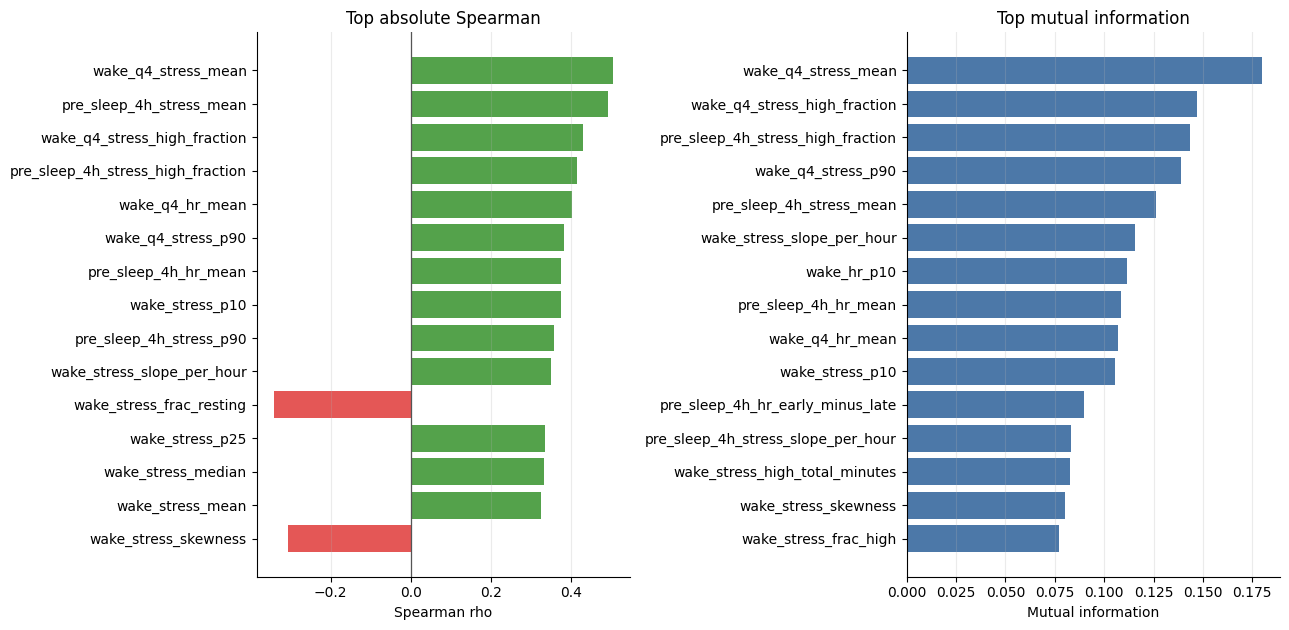

In [13]:
from sklearn.feature_selection import mutual_info_regression

association_feature_set = "aggregate_plus_monitoring_full"
association_features = (
    feature_catalog.loc[feature_catalog["feature_set"] == association_feature_set, "feature"]
    .drop_duplicates()
    .tolist()
)
association_features = [feature for feature in association_features if feature in frame.columns]

association_train = frame.loc[
    frame[STAGE4_SPLIT_COLUMN] == "train",
    [STAGE4_PRIMARY_TARGET, *association_features],
].copy()
association_y = pd.to_numeric(association_train[STAGE4_PRIMARY_TARGET], errors="coerce")

numeric_feature_series = {}
for feature in association_features:
    values = pd.to_numeric(association_train[feature], errors="coerce").replace([np.inf, -np.inf], np.nan)
    if values.notna().sum() >= 50 and values.nunique(dropna=True) > 1:
        numeric_feature_series[feature] = values

association_x = pd.DataFrame(numeric_feature_series)
target_mask = association_y.notna()
association_x = association_x.loc[target_mask]
association_y = association_y.loc[target_mask]

association_x = association_x.loc[:, association_x.notna().mean() >= 0.60]
association_spearman = association_x.corrwith(association_y, method="spearman")
association_x_mi = association_x.fillna(association_x.median(numeric_only=True))
mi_scores = mutual_info_regression(association_x_mi, association_y, random_state=42)

association_scores = pd.DataFrame(
    {
        "feature": association_x_mi.columns,
        "spearman": association_spearman.reindex(association_x_mi.columns).to_numpy(),
        "mutual_information": mi_scores,
    }
)
association_scores["abs_spearman"] = association_scores["spearman"].abs()

association_summary = pd.DataFrame(
    [
        {
            "feature_set": association_feature_set,
            "train_rows": len(association_y),
            "numeric_features_scored": len(association_scores),
            "non_numeric_or_sparse_features_skipped": len(association_features) - len(association_scores),
        }
    ]
)
display(association_summary)

top_spearman = association_scores.sort_values("abs_spearman", ascending=False).head(15)
top_mi = association_scores.sort_values("mutual_information", ascending=False).head(15)
display(top_spearman[["feature", "spearman", "mutual_information"]])
display(top_mi[["feature", "spearman", "mutual_information"]])

spearman_plot = top_spearman.sort_values("abs_spearman")
mi_plot = top_mi.sort_values("mutual_information")

fig, axes = plt.subplots(1, 2, figsize=(13, 6.4))
spearman_colors = np.where(spearman_plot["spearman"] >= 0, "#54a24b", "#e45756")
axes[0].barh(spearman_plot["feature"], spearman_plot["spearman"], color=spearman_colors)
axes[0].axvline(0, color="#555555", linewidth=0.9)
axes[0].set_title("Top absolute Spearman")
axes[0].set_xlabel("Spearman rho")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(mi_plot["feature"], mi_plot["mutual_information"], color="#4c78a8")
axes[1].set_title("Top mutual information")
axes[1].set_xlabel("Mutual information")
axes[1].grid(axis="x", alpha=0.25)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Feature Missingness Review

In [14]:
missing_review = (
    feature_catalog.sort_values(["feature_set", "modeling_missing_pct", "feature"], ascending=[True, False, True])
    .groupby("feature_set")
    .head(8)
    [["feature_set", "feature", "family", "phase", "window", "modeling_missing_pct"]]
    .reset_index(drop=True)
)
display(missing_review)

,feature_set,feature,family,phase,window,modeling_missing_pct
0,aggregate_plus_monitoring_full,wake_hr_zone2_plus_time_to_first_minutes,episodes/state structure,wake,wake_phase,15.254237
1,aggregate_plus_monitoring_full,pre_sleep_4h_hr_early_minus_late,recovery/deactivation,wake/pre-sleep,pre_sleep_4h,1.271186
2,aggregate_plus_monitoring_full,pre_sleep_4h_stress_early_minus_late,recovery/deactivation,wake/pre-sleep,pre_sleep_4h,1.271186
3,aggregate_plus_monitoring_full,wake_q2_stress_high_fraction,relative windows,wake,wake_q2,0.423729
4,aggregate_plus_monitoring_full,wake_q2_stress_mean,relative windows,wake,wake_q2,0.423729
5,aggregate_plus_monitoring_full,wake_q2_stress_p90,relative windows,wake,wake_q2,0.423729
6,aggregate_plus_monitoring_full,wake_q2_stress_std,relative windows,wake,wake_q2,0.423729
7,aggregate_plus_monitoring_full,agg__activeKilocalories,non_overlapping_day_context,aggregate,day_D,0.000000
8,aggregate_stage3_baseline,agg__awakeRestHours,direct_monitoring_overlap,aggregate,day_D,0.635593
9,aggregate_stage3_baseline,agg__awakeRestShare,direct_monitoring_overlap,aggregate,day_D,0.635593


## Aggregate Candidate Review

In [15]:
aggregate_review = (
    feature_catalog.loc[feature_catalog["feature_set"] == "aggregate_stage3_baseline"]
    [[
        "feature",
        "aggregate_review_group",
        "included_in_aggregate_plus_monitoring_full",
        "modeling_missing_pct",
    ]]
    .sort_values(["included_in_aggregate_plus_monitoring_full", "aggregate_review_group", "feature"], ascending=[False, True, True])
)
display(
    aggregate_review.groupby(["aggregate_review_group", "included_in_aggregate_plus_monitoring_full"], as_index=False)
    .size()
    .rename(columns={"size": "features"})
)
display(aggregate_review)

,aggregate_review_group,included_in_aggregate_plus_monitoring_full,features
0,direct_monitoring_overlap,False,17
1,non_overlapping_day_context,True,15


,feature,aggregate_review_group,included_in_aggregate_plus_monitoring_full,modeling_missing_pct
2,agg__activeKilocalories,non_overlapping_day_context,True,0.000000
3,agg__active_hours,non_overlapping_day_context,True,0.000000
9,agg__bodyBatteryHighest,non_overlapping_day_context,True,0.000000
8,agg__bodyBatteryLowest,non_overlapping_day_context,True,0.000000
12,agg__bodyBatteryNetBalance,non_overlapping_day_context,True,0.000000
10,agg__bodyBattery_chargedValue,non_overlapping_day_context,True,0.000000
11,agg__bodyBattery_drainedValue,non_overlapping_day_context,True,0.000000
13,agg__floorsAscendedInMeters,non_overlapping_day_context,True,0.000000
14,agg__floorsDescendedInMeters,non_overlapping_day_context,True,0.000000
4,agg__highly_active_hours,non_overlapping_day_context,True,0.000000


## Contract Checks

In [16]:
monitoring_sets = ["monitoring_core_wake_pre_sleep", "monitoring_full_wake_pre_sleep"]
monitoring_features = feature_catalog.loc[feature_catalog["feature_set"].isin(monitoring_sets), "feature"].astype(str)
sleep_feature_leaks = monitoring_features[monitoring_features.str.startswith("sleep_")]
assert sleep_feature_leaks.empty, sleep_feature_leaks.tolist()

split_labels = set(frame[STAGE4_SPLIT_COLUMN].dropna().unique())
assert split_labels <= {"train", "valid", "test", STAGE4_NON_MODELING_LABEL}
assert int((eligible & primary_target_available).sum()) == int(modeling_rows.sum())

print("Contract checks passed.")

Contract checks passed.


## Audit Takeaways

- The modeling frame has one row per Stage 4 analysis window and keeps eligibility visible rather than silently dropping non-modeling rows.
- The primary target is next-sleep `avgSleepStress`, with secondary score, opportunity, and start-time targets retained for audit.
- The default split keeps the final eligible target-available block as test, while train and validation are randomized within the earlier history.
- Monitoring feature sets are wake/pre-sleep only. Sleep-phase monitoring summaries are available in source tables but are not part of these predictor definitions.
- Aggregate features are prefixed and reviewed separately so later modeling notebooks can decide how much aggregate context to include.
- PCA split projection is fitted on train-only numeric predictors and used only as an X-shift diagnostic.
- `next_sleep_start_hour_local_wrapped` is included as sleep-start schedule context because this frame is defined at the end of the wake/pre-sleep window.